In [1]:
# =============================================================================
# LSTM.ipynb — LSTM Baseline for Realized Volatility Forecasting
# =============================================================================
#
# This notebook implements two LSTM (Long Short-Term Memory) neural network
# baselines for the paper:
#   "Quantum Reservoir Computing for Realized Volatility Forecasting"
#   (arXiv:2505.13933)
#
# Two model variants are trained:
#   1. LSTM  — Uses only RV (realized volatility) as input, hidden_size=60
#   2. LSTMX — Uses all 11 macro-financial features as input, hidden_size=50
#
# Both use a rolling-window approach: for each of the 245 out-of-sample
# months, the model is re-trained from scratch on the most recent 571
# observations, then produces a single 1-step-ahead forecast.
#
# OUTPUTS:
#   - results/predictions/LSTM/lstm60_predictions.csv   (245 predictions from base LSTM)
#   - results/predictions/LSTM/lstmx50_predictions.csv  (245 predictions from extended LSTMX)
#   - results/predictions/LSTM/lstm_comparison.png      (visual comparison plot)
#
# These prediction files are consumed by Reservoir_Learning.ipynb for
# the final Model Confidence Set (MCS) and Diebold-Mariano comparisons.
#
# PREREQUISITES:
#   - Run `python preprocess.py` first to generate data/dff.csv and data/Data_raw.csv
#
# Paper reference: Section III.B, Appendix D (hyperparameter selection)
# =============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output directory for LSTM prediction files
os.makedirs("results/predictions/LSTM", exist_ok=True)

# Use GPU if available (speeds up training significantly)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:{}".format(device))

# =============================================================================
# LSTM Model Architecture
# =============================================================================
# The model is a standard stacked LSTM followed by a fully-connected output
# layer. It takes a sequence of K time steps as input and produces a single
# scalar prediction (next month's RV).
#
# Architecture:
#   Input: (batch_size, K=3, n_features) — K months of feature data
#   -> LSTM layers (2 stacked, hidden_size varies)
#   -> Take last time step's hidden state: (batch_size, hidden_size)
#   -> Fully connected layer: (batch_size, 1)
#   Output: Predicted RV for the next month
#
# Paper spec (Appendix D):
#   - num_layers=2 (stacked LSTM)
#   - hidden_size scanned from 10 to 200 in steps of 10
#   - Best: LSTM=60, LSTMX=50
# =============================================================================
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        """
        Parameters
        ----------
        input_size : int
            Number of input features per time step (1 for LSTM, 11 for LSTMX).
        hidden_size : int
            Dimensionality of the LSTM hidden state (60 or 50).
        num_layers : int
            Number of stacked LSTM layers (2 per paper).
        output_size : int
            Number of output values (always 1 — single RV prediction).
        """
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Stacked LSTM: batch_first=True means input shape is (batch, seq_len, features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # Linear output layer maps hidden state to a single predicted value
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        """
        Forward pass through the LSTM.
        
        Parameters
        ----------
        x : torch.Tensor
            Shape (batch_size, K, input_size) — K time steps of features.
        
        Returns
        -------
        torch.Tensor
            Shape (batch_size, 1) — predicted RV for next month.
        """
        # Initialize hidden state and cell state to zeros
        # Shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Run LSTM over the input sequence
        # out shape: (batch_size, K, hidden_size) — hidden states at each time step
        out, _ = self.lstm(x, (h0, c0))
        
        # Take only the LAST time step's hidden state for prediction
        # This captures the full K-step context
        out = out[:, -1, :]  # Shape: (batch_size, hidden_size)
        
        # Map to single output value
        out = self.fc(out)   # Shape: (batch_size, 1)
        return out


device:cpu


In [2]:
# =============================================================================
# Load the differenced dataset (data/dff.csv)
# =============================================================================
# data/dff.csv is generated by preprocess.py. It contains 816 rows (monthly
# observations from Jan 1950 to Dec 2017) with columns that have been
# ADF-tested for stationarity. Non-stationary columns (DP, TB) have been
# replaced by their first differences (diff_DP, diff_TB).
#
# Note: STR (Short-Term Reversal factor) is NOT included in data/dff.csv because
# the ADF differencing in preprocess.py processes columns from Data.CSV, and
# STR's handling requires special treatment. We add it in cell 3 below.
dff = pd.read_csv("data/dff.csv", header=0, index_col=0)
dff = dff.fillna(0)  # Fill any remaining NaN values with 0


In [3]:
# =============================================================================
# Load the raw (un-differenced) dataset
# =============================================================================
# We need the raw data to extract the STR column, which is stationary
# and should be used as-is (not differenced).
dff1 = pd.read_csv("data/Data_raw.csv", header=0, index_col=0)


In [4]:
# =============================================================================
# Add STR (Short-Term Reversal factor) from the raw dataset
# =============================================================================
# STR is a Fama-French factor measuring average return of low-prior-return
# stocks minus high-prior-return stocks. It is stationary and used as-is.
dff["STR"] = dff1["STR"]


In [5]:
# =============================================================================
# Rolling Window Parameters
# =============================================================================
# The paper uses a rolling-window out-of-sample evaluation:
#   - Total observations: 816 months (Jan 1950 - Dec 2017)
#   - Out-of-sample test: last 245 months (Aug 1997 - Dec 2017)
#   - Training window: 571 months (fixed size, slides forward by 1 each step)
#
# For each of the 245 test months, a fresh LSTM model is trained on the
# preceding 571 months and makes a 1-step-ahead prediction.
#
# Paper reference: Section III.A, "rolling window" approach
# =============================================================================
L = 245       # Number of out-of-sample predictions (Aug 1997 - Dec 2017)
Total = 816   # Total number of monthly observations in the dataset
WL = Total - L  # Training window length = 571 months
ws = 0        # Window start index (0 = full sample; 277 = subsample)


In [6]:
# =============================================================================
# Extract the target variable: Realized Volatility (RV)
# =============================================================================
# RV is log(realized volatility), normalized to the range [-1, 0].
# This is the variable all models are trying to predict.
# Shape: (816, 1) — one value per month
RV = np.array(dff['RV'], dtype=np.float32).reshape(-1, 1)


In [7]:
# =============================================================================
# Feature List (11 macro-financial predictors)
# =============================================================================
# These 11 features are used by the LSTMX (extended) model variant.
# The base LSTM model uses only ["RV"].
#
# Feature descriptions (from paper Table I):
#   RV      — Log realized volatility (target, also used as input)
#   MKT     — Fama-French market excess return
#   diff_DP — First difference of dividend-price ratio (differenced for stationarity)
#   IP      — Industrial production growth rate
#   DEF     — Default spread (credit risk proxy)
#   EP      — Earnings-price ratio
#   SMB     — Fama-French size premium factor (small minus big)
#   diff_TB — First difference of 3-month T-bill rate (differenced for stationarity)
#   HML     — Fama-French value factor (high minus low)
#   INF     — Monthly US inflation rate
#   STR     — Fama-French short-term reversal factor
F = ["RV", "MKT", "diff_DP", "IP", "DEF", "EP", "SMB", "diff_TB", "HML", "INF", "STR"]
features = len(F)  # = 11


In [8]:
# =============================================================================
# Convert feature data to numpy array for efficient slicing
# =============================================================================
# Shape: (816, 11) — all 11 features for all 816 months
Data = np.array(dff[F], dtype=np.float32).reshape(-1, features)


In [9]:
# =============================================================================
# Extract the test set (last 245 months) for plotting
# =============================================================================
# Used for x-axis labels in comparison plots. The actual test predictions
# are computed inside the rolling window loop.
test = dff.iloc[-245:]


In [10]:
# =============================================================================
# LSTM Hyperparameters (from paper Appendix D)
# =============================================================================
# The paper scanned hidden_size from 10 to 200 in increments of 10.
# Best configurations:
#   - LSTM (RV only):    hidden_size=60
#   - LSTMX (11 features): hidden_size=50
#
# Other hyperparameters are shared across both variants:
#   - num_layers=2      (stacked LSTM, paper Section III.B)
#   - batch_size=64     (paper specification)
#   - num_epochs=100    (training epochs per rolling window)
#   - learning_rate=0.001 (Adam optimizer)
#   - K=3               (sequence length: use 3 months to predict next month)
# =============================================================================
num_layers = 2        # Number of stacked LSTM layers
output_size = 1       # Single output: predicted RV
num_epochs = 100      # Training epochs per window
batch_size = 64       # Mini-batch size (paper: 64)
learning_rate = 0.001 # Adam learning rate
K = 3                 # Sequence length (lookback window of 3 months)


In [11]:
# =============================================================================
# Training Function
# =============================================================================
def train_model(model, train_loader, optimizer, criterion):
    """
    Train the LSTM model for num_epochs over the given training data.
    
    Parameters
    ----------
    model : LSTMModel
        The LSTM model to train.
    train_loader : DataLoader
        PyTorch DataLoader providing (input, target) mini-batches.
    optimizer : torch.optim.Optimizer
        Adam optimizer for gradient updates.
    criterion : nn.Module
        Loss function (MSE loss).
    
    Returns
    -------
    LSTMModel
        The trained model.
    """
    for epoch in range(num_epochs):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            optimizer.zero_grad()  # Clear previous gradients
            loss.backward()        # Compute gradients via backpropagation
            optimizer.step()       # Update model weights
    return model


# =============================================================================
# Rolling-Window LSTM Forecasting
# =============================================================================
def run_lstm_rolling(feature_list, hidden_size, K=3):
    """
    Run 245 rolling-window LSTM trainings and return out-of-sample predictions.
    
    For each of the 245 test months (Aug 1997 - Dec 2017):
      1. Construct training sequences from the current 571-month window
      2. Train a fresh LSTM model from scratch
      3. Use the last K=3 months to predict the next month's RV
      4. Slide the window forward by 1 month
    
    This is computationally expensive: 245 models x 100 epochs each.
    
    Parameters
    ----------
    feature_list : list of str
        Column names to use as input features.
        ["RV"] for base LSTM, all 11 for LSTMX.
    hidden_size : int
        LSTM hidden state dimensionality (60 for LSTM, 50 for LSTMX).
    K : int
        Sequence length (number of past months used as input). Default 3.
    
    Returns
    -------
    np.ndarray
        Shape (245, 1) — one prediction per out-of-sample month.
    """
    n_feat = len(feature_list)
    data_arr = np.array(dff[feature_list], dtype=np.float32).reshape(-1, n_feat)
    
    predictions = np.zeros((L, 1))  # 245 predictions
    ws = 0  # Current window start position
    
    while ws < L:
        # ---- Step 1: Create a fresh model for this window ----
        model = LSTMModel(n_feat, hidden_size, num_layers, output_size).to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()

        # ---- Step 2: Build training sequences ----
        # From the current 571-month window, create (WL-K) training samples.
        # Each sample: input = K consecutive months, target = RV of month K+1
        #
        # Example for ws=0, K=3, WL=571:
        #   Sample 0: input=[month 0,1,2], target=RV[3]
        #   Sample 1: input=[month 1,2,3], target=RV[4]
        #   ...
        #   Sample 567: input=[month 567,568,569], target=RV[570]
        x_train = torch.zeros(WL - K, K, n_feat)
        y_train = torch.from_numpy(RV[ws + K:ws + WL])  # Targets: RV values
        
        for t in range(WL - K):
            X = np.array(data_arr[ws + t:ws + t + K, :]).reshape(-1, n_feat)
            x_train[t, :, :] = torch.from_numpy(X)
        
        # Create PyTorch dataset and dataloader for mini-batch training
        train_dataset = TensorDataset(x_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        # ---- Step 3: Train the model ----
        model = train_model(model, train_loader, optimizer, criterion)
        
        # ---- Step 4: Make the out-of-sample prediction ----
        # Use the LAST K months of the training window as input
        # to predict the first out-of-sample month
        x_test = torch.zeros(1, K, n_feat).to(device)
        x_test[0, :, :] = torch.from_numpy(
            np.array(data_arr[ws + WL - K:ws + WL]).reshape(-1, n_feat)
        )
        
        model.eval()  # Switch to evaluation mode (disables dropout if any)
        with torch.no_grad():  # No gradient computation needed for inference
            predictions[ws, 0] = model(x_test)
        
        # ---- Step 5: Slide the window forward by 1 month ----
        ws += 1
        if ws % 50 == 0:
            print(f"  Window {ws}/{L}")
    
    return predictions


In [12]:
# =============================================================================
# Run 1: Base LSTM (RV-only input, hidden_size=60)
# =============================================================================
# This is the base LSTM model that uses only past realized volatility
# (no exogenous macro predictors) to forecast next month's RV.
# Paper Appendix D: best hidden_size = 60 (from scanning 10-200).
#
# Output: results/predictions/LSTM/lstm60_predictions.csv (245 rows, 1 column)
F_base = ["RV"]
print("Training LSTM (base, RV-only, hidden=60) ...")
predictions_lstm = run_lstm_rolling(F_base, hidden_size=60)
np.savetxt("results/predictions/LSTM/lstm60_predictions.csv", predictions_lstm, delimiter=',')
print("Saved results/predictions/LSTM/lstm60_predictions.csv")
print("MSE:", np.mean((predictions_lstm - RV[WL:]) ** 2))


Training LSTM (base, RV-only, hidden=60) ...


  Window 50/245


  Window 100/245


  Window 150/245


  Window 200/245


Saved LSTM/lstm60_predictions.csv
MSE: 0.010458508397679091


In [13]:
# =============================================================================
# Run 2: LSTMX (11 macro-financial features, hidden_size=50)
# =============================================================================
# The extended LSTM model uses all 11 features (RV + 10 macro predictors)
# as input. This tests whether additional macro information improves
# volatility forecasting. Paper Appendix D: best hidden_size = 50.
#
# Output: results/predictions/LSTM/lstmx50_predictions.csv (245 rows, 1 column)
F_ext = ["RV", "MKT", "diff_DP", "IP", "DEF", "EP", "SMB", "diff_TB", "HML", "INF", "STR"]
print("Training LSTMX (extended, 11 features, hidden=50) ...")
predictions_lstmx = run_lstm_rolling(F_ext, hidden_size=50)
np.savetxt("results/predictions/LSTM/lstmx50_predictions.csv", predictions_lstmx, delimiter=',')
print("Saved results/predictions/LSTM/lstmx50_predictions.csv")
print("MSE:", np.mean((predictions_lstmx - RV[WL:]) ** 2))


Training LSTMX (extended, 11 features, hidden=50) ...


  Window 50/245


  Window 100/245


  Window 150/245


  Window 200/245


Saved LSTM/lstmx50_predictions.csv
MSE: 0.009024157767498434


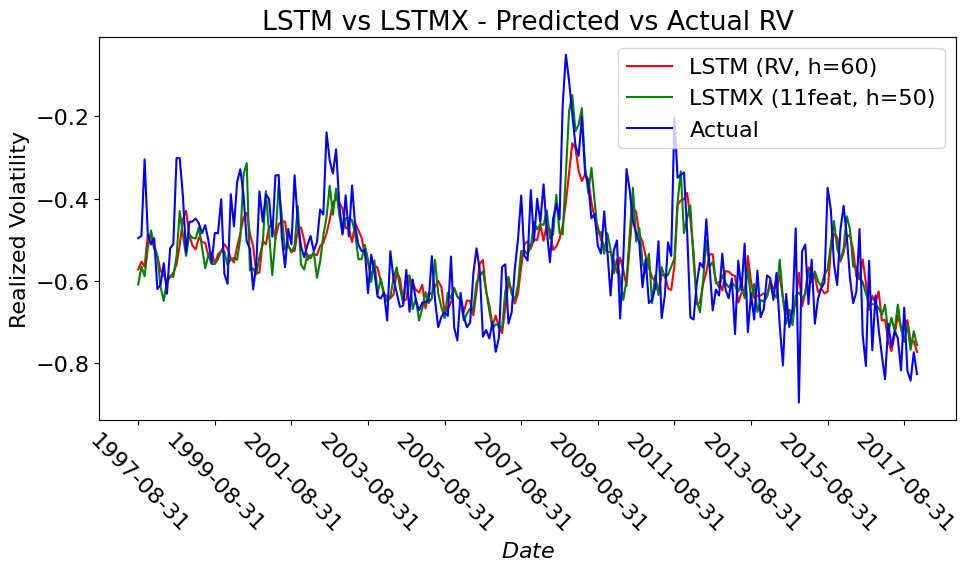

In [14]:
# =============================================================================
# Comparison Plot: LSTM vs LSTMX vs Actual RV
# =============================================================================
# Visual sanity check: both predictions should track the actual RV curve.
# LSTMX (with macro features) may show smoother or more accurate tracking.
plt.figure(figsize=(10, 6))
plt.rcParams['font.size'] = 16
plt.title("LSTM vs LSTMX - Predicted vs Actual RV")
plt.xlabel("$Date$")
plt.plot(test.index, predictions_lstm, label="LSTM (RV, h=60)", color="red")
plt.plot(test.index, predictions_lstmx, label="LSTMX (11feat, h=50)", color="green")
plt.plot(test.index, RV[WL:], label="Actual", color="blue")
plt.xticks(test.index[::24], rotation=-45)
plt.ylabel('Realized Volatility')
plt.tight_layout() 
plt.legend()
plt.savefig("results/predictions/LSTM/lstm_comparison.png")
plt.show()


In [15]:
# =============================================================================
# QLIKE Loss Functions
# =============================================================================
# QLIKE (Quasi-Likelihood) is an asymmetric loss function from Patton (2011)
# designed for volatility forecast evaluation. Unlike MSE, QLIKE penalizes
# underestimation of volatility more heavily — this is economically meaningful
# because underestimating risk is more dangerous than overestimating it.
#
# Formula: QLIKE = sum( sigma^2/h^2 - log(sigma^2/h^2) - 1 )
#   where sigma^2 = actual variance, h^2 = forecasted variance
#
# Note: Two different QLIKE implementations exist here:
#   1. compute_qlike() — sum-based, used for individual model evaluation
#   2. qlike_loss()    — mean-based alternative (not used in final MCS)
# =============================================================================
def compute_qlike(forecasts, actuals):
    """
    Compute sum-based QLIKE loss between forecasted and actual volatility.
    Uses absolute values to handle negative log-RV values.
    
    Parameters
    ----------
    forecasts : np.ndarray
        Model predictions (in normalized [-1, 0] scale).
    actuals : np.ndarray
        True realized volatility values.
    
    Returns
    -------
    float
        Total QLIKE loss (lower is better).
    """
    forecasts = np.abs(forecasts)
    actuals = np.abs(actuals)
    ratio = actuals / forecasts
    qlike = np.sum(ratio - np.log(ratio) - 1)
    return qlike


def qlike_loss(y_true, y_hat):
    """
    Alternative mean-based QLIKE loss (not used in final paper comparison).
    """
    eps = np.finfo(float).eps
    w = np.abs(y_true - y_hat) / (y_hat + eps)
    return np.mean(np.log(1 + w**2))


In [16]:
# Extract actual RV values for the 245-month test period
actual = RV[WL:]  # Shape: (245, 1)


In [17]:
# =============================================================================
# Print MSE and QLIKE metrics for both LSTM variants
# =============================================================================
# These are quick sanity checks. The definitive comparison happens in
# Reservoir_Learning.ipynb using the Model Confidence Set.
print("--- LSTM (base, RV-only, hidden=60) ---")
qlike1 = qlike_loss(np.array(actual), np.array(predictions_lstm))
print(f"  QLIKE loss: {qlike1}")
mse1 = np.mean((predictions_lstm - actual) ** 2)
print(f"  MSE: {mse1}")

print("\n--- LSTMX (extended, 11 features, hidden=50) ---")
qlike2 = qlike_loss(np.array(actual), np.array(predictions_lstmx))
print(f"  QLIKE loss: {qlike2}")
mse2 = np.mean((predictions_lstmx - actual) ** 2)
print(f"  MSE: {mse2}")


--- LSTM (base, RV-only, hidden=60) ---
  QLIKE loss: 0.034917655937259096
  MSE: 0.010458508397679091

--- LSTMX (extended, 11 features, hidden=50) ---
  QLIKE loss: 0.03204510445774235
  MSE: 0.009024157767498434
